In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("synthetic_transactions.csv")

# Quick look
print(df.head())
print(df.info())


   user_id   amount                   timestamp   device_id      receiver  \
0        1   860.92  2026-01-04T11:36:59.972147  device_1_1  merchant_1_1   
1        1   981.18  2026-01-04T12:27:39.972147  device_1_1  merchant_1_1   
2        1  1681.93  2026-01-04T12:33:03.972147  device_1_1  merchant_1_1   
3        1    90.52  2026-01-04T13:25:43.972147  device_1_1  merchant_1_1   
4        1  1190.03  2026-01-04T14:10:40.972147  device_1_1  merchant_1_1   

   hour  is_night  time_gap  device_change  location_change  is_fraud  
0    11         0    2274.0              0                0         0  
1    12         0    3040.0              0                1         0  
2    12         0     324.0              0                0         0  
3    13         0    3160.0              0                0         0  
4    14         0    2697.0              0                0         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns)

In [2]:
# Drop non-numeric / identifier columns
X = df.select_dtypes(include=["int64", "float64"])

print(X.columns)


Index(['user_id', 'amount', 'hour', 'is_night', 'time_gap', 'device_change',
       'location_change', 'is_fraud'],
      dtype='object')


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(
    n_estimators=200,          # Number of trees (100-200 is robust for fraud)
    max_samples='auto',        # Uses 256 samples per tree (best for isolating anomalies)
    contamination=0.02,        # Expecting ~2% of transactions to be anomalies/fraud
    max_features=1.0,          # Use all 6 generated features for every tree
    bootstrap=False,           # Don't resample data (standard IF logic)
    n_jobs=-1,                 # Use all CPU cores for faster training
    random_state=42,           # Ensures reproducible results
    verbose=0
)
df["anomaly"] = iso_forest.fit_predict(X_scaled)

In [6]:
# Count anomalies
print(df["anomaly"].value_counts())


anomaly
 1    1960
-1      40
Name: count, dtype: int64


In [7]:
anomalies = df[df["anomaly"] == -1]
print(anomalies.head())

     user_id   amount                   timestamp    device_id      receiver  \
25         1  1931.08  2026-01-04T22:58:37.972147   device_1_6  merchant_251   
105        3   352.44  2026-01-05T01:47:02.972147  device_3_87  merchant_408   
108        3  1650.14  2026-01-05T03:53:59.972147  device_3_87  merchant_408   
111        3   444.41  2026-01-05T04:37:40.972147  device_3_22  merchant_915   
144        4   757.60  2026-01-05T00:51:24.972147  device_4_76  merchant_355   

     hour  is_night  time_gap  device_change  location_change  is_fraud  \
25     22         0    1529.0              1                1         0   
105     1         1    3117.0              1                0         0   
108     3         1    3552.0              0                1         0   
111     4         1     154.0              1                0         0   
144     0         1     261.0              1                0         0   

     anomaly  
25        -1  
105       -1  
108       -1  
111     

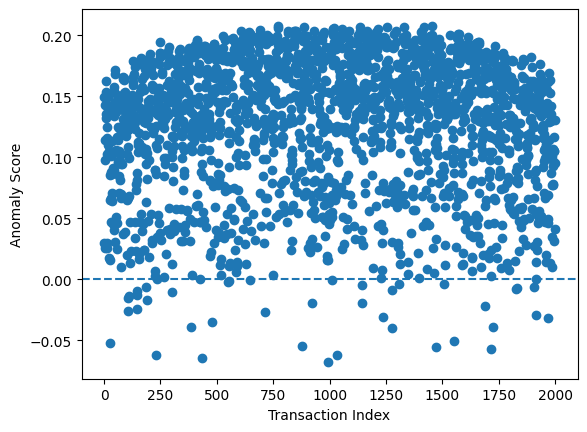

In [9]:
import matplotlib.pyplot as plt
df["anomaly_score"] = iso_forest.decision_function(X_scaled)

plt.figure()
plt.scatter(df.index, df["anomaly_score"])
plt.axhline(y=0, linestyle="--")
plt.xlabel("Transaction Index")
plt.ylabel("Anomaly Score")
plt.show()

In [10]:
import pickle

# Save Isolation Forest model
with open("isolation_forest.pkl", "wb") as f:
    pickle.dump(iso_forest, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
